In [1]:
# Автоматическая перезагрузка модулей при изменении
# Позволяет обновлять код в helper.py, plots.py, nlp.py без перезапуска ядра
%load_ext autoreload
%autoreload 2

In [2]:
# Импорт библиотек для машинного обучения и обработки текста
import pandas as pd
import numpy as np
import random

# Импорт sklearn для классических алгоритмов ML
from sklearn.model_selection import train_test_split, StratifiedKFold  # разделение данных и кросс-валидация
from sklearn.dummy import DummyClassifier  # наивный классификатор для бейслайна
from sklearn.compose import ColumnTransformer  # трансформация разных столбцов по-разному
from sklearn.pipeline import Pipeline  # создание пайплайнов обработки
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer  # векторизация текста
from sklearn.linear_model import LogisticRegression  # логистическая регрессия
from sklearn.tree import DecisionTreeClassifier  # дерево решений
from sklearn.ensemble import RandomForestClassifier  # случайный лес
from sklearn.base import clone  # клонирование моделей
from lightgbm import LGBMClassifier  # градиентный бустинг

# Пользовательские модули
from helper import *  # вспомогательные функции
from plots import *   # функции визуализации
from nlp import *     # функции обработки естественного языка
from transformers import *  # функции для работы с трансформерами

In [3]:
# Фиксация состояния генератора псевдослучайных чисел для воспроизводимости
# Критически важно для машинного обучения - результаты должны быть воспроизводимы
SEED = 42 # можно указать любое число
np.random.seed(SEED)  # для numpy операций
random.seed(SEED)     # для стандартного модуля random

In [4]:
# Загружаем предобработанные данные
df = pd.read_csv('Data/movie.csv')

## 1. Препроцессинг данных

### 1.1 Общие преобразования

In [5]:
# Создаем копию данных для предобработки
df_preprocessed = df.copy()
# удалим дубликаты
df_preprocessed = df_preprocessed.drop_duplicates()

# Токенизируем тексты с помощью tiktoken (токенизатор GPT)
# Это необходимо для дальнейшей векторизации текстов
df_preprocessed['text'] = df_preprocessed['text'].apply(tokenize_tiktoken)

In [6]:
# Разделяем данные на признаки (X) и целевую переменную (y)
X, y = divide_data(df_preprocessed, 'label')

## 2. Построение baseline

In [7]:
# Определяем набор baseline моделей для сравнения:
models = [
    ('DummyClassifier', DummyClassifier(random_state=SEED, strategy='most_frequent')),  # наивный классификатор
    ('LogisticRegression', LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear')),  # линейная модель
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=SEED, max_depth=4)),  # дерево решений
    ('RandomForestClassifier', RandomForestClassifier(random_state=SEED)),  # случайный лес
    ('LGBMClassifier', LGBMClassifier(random_state=SEED, verbose=-1))  # градиентный бустинг
]

In [8]:
# Настраиваем стратифицированную кросс-валидацию с 5 фолдами
# StratifiedKFold гарантирует, что в каждом фолде будет примерно одинаковое соотношение классов
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### 2.1. CountVectorizer

#### 2.1.1 Без очистки токенов

In [9]:
# Создаем пайплайн для векторизации текстов
count_vectorizer_preprocessor = Pipeline([
    ('vectorizer', ColumnTransformer(
        [
            # Векторизация описаний: min_df=50 исключает слова, встречающиеся менее 50 раз
            ('description_vectorizer', CountVectorizer(analyzer=lambda x: x, min_df=50, dtype=np.float32), 'text'),
        ],
        remainder='passthrough',  # остальные столбцы передаем как есть
        verbose_feature_names_out=True  # для отладки имен признаков
    )),
])

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

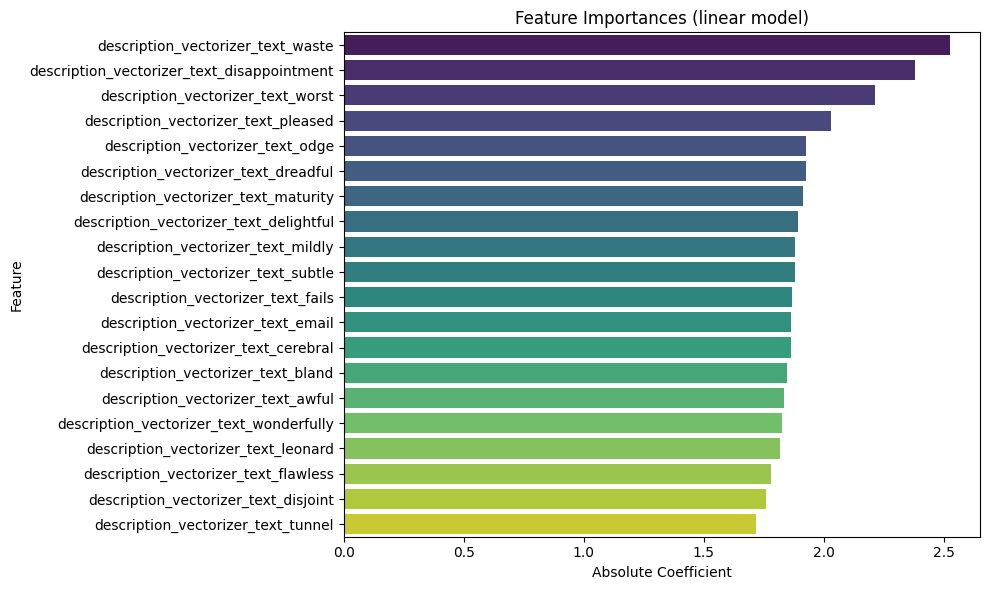

<Figure size 1500x600 with 0 Axes>

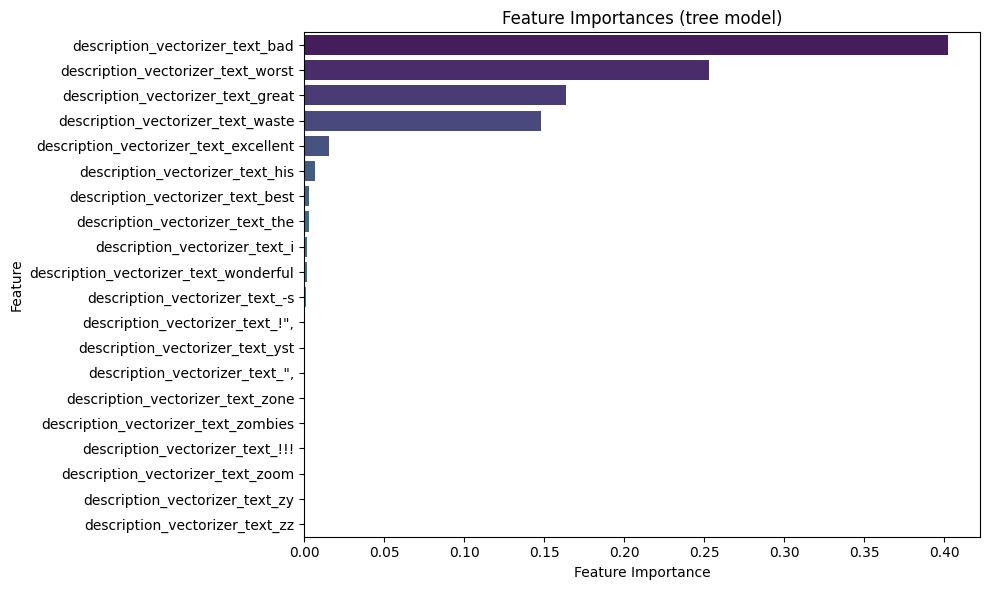

<Figure size 1500x600 with 0 Axes>

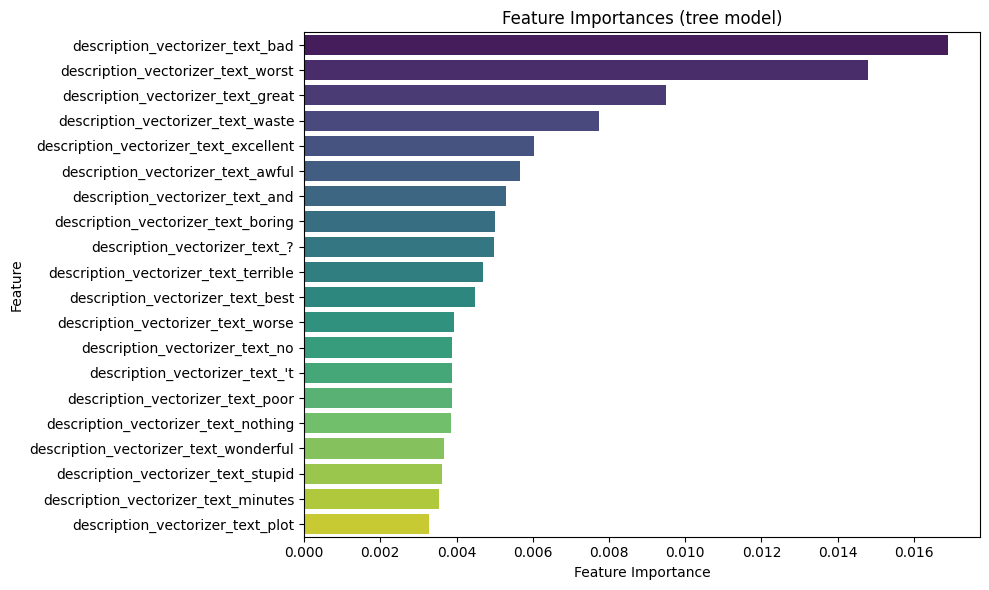

c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.

<Figure size 1500x600 with 0 Axes>

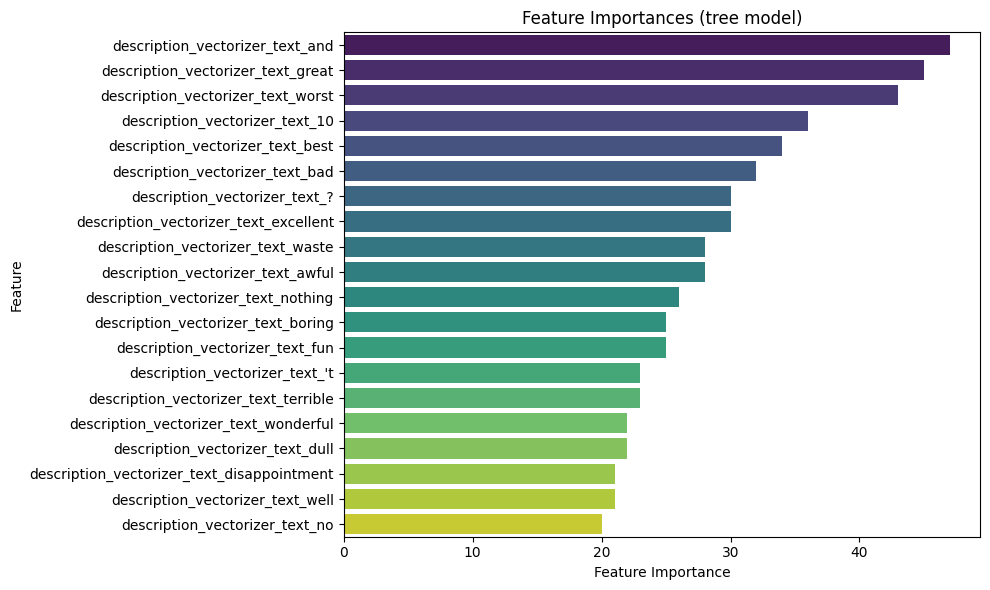

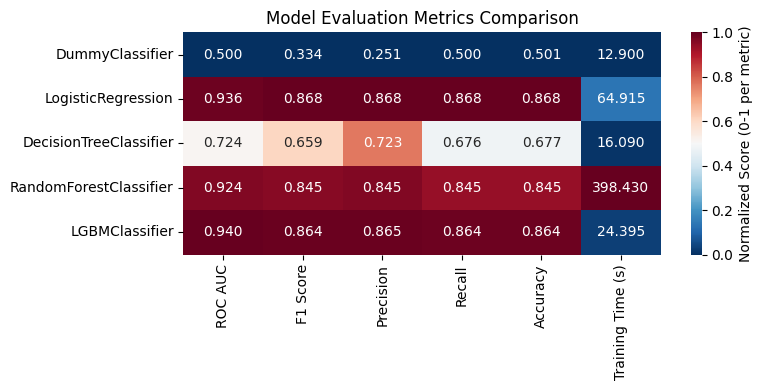

In [10]:
# Обучаем все baseline модели с кросс-валидацией
# Функция автоматически обучает каждую модель, оценивает метрики и строит графики важности признаков
count_vectorizer_metrics = train_evaluate_models_cv(
    models=models,
    X=X,
    y=y,
    preprocessor=count_vectorizer_preprocessor,
    cv=cv,
    seed=SEED
)

Анализ важности признаков:

На графиках feature importance мы видим, что важными фичами стали прилагательные great, worst и тд. Что довольно характерно для отзывов. 

#### 2.1.2 Удалим стоп-слова

In [11]:
# Создаем копию данных для экспериментов с очисткой
X_cleaned_tokens = X.copy()

# Удаляем стоп-слова из токенов, но оставляем пунктуацию
# lowercase_for_counting=True приводит все к нижнему регистру для корректного подсчета
X_cleaned_tokens[['text']] = X_cleaned_tokens[['text']].map(lambda tokens: filter_tokens(
    tokens, 
    remove_stopwords=True, 
    remove_punct_tokens=True,
    lowercase_for_counting=True
))

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

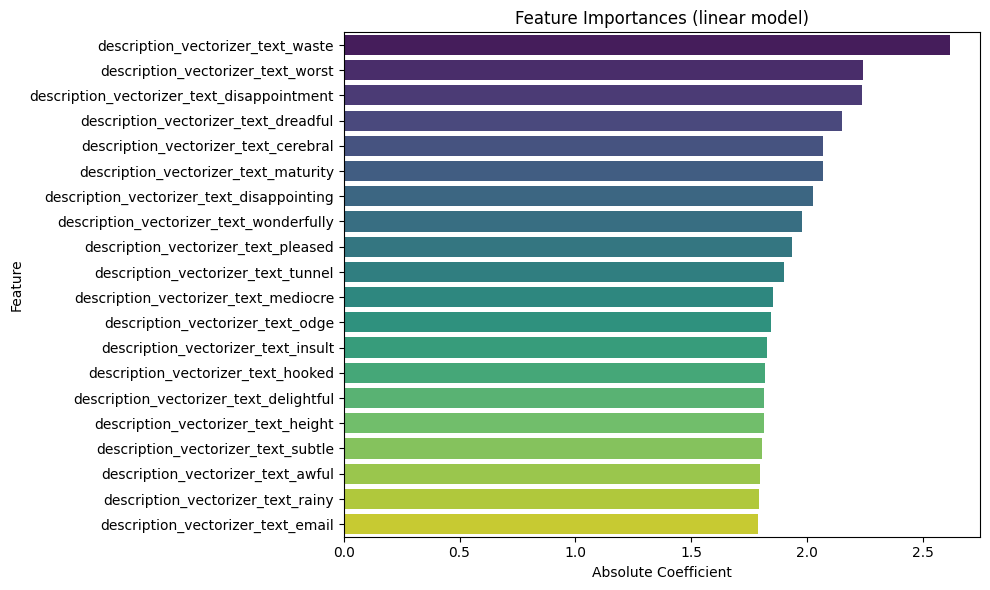

<Figure size 1500x600 with 0 Axes>

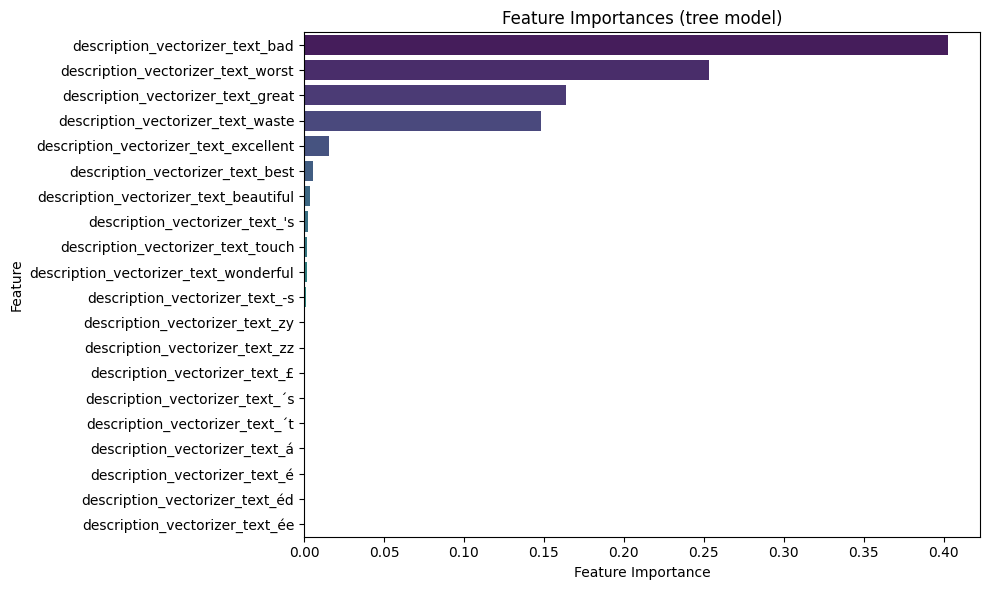

<Figure size 1500x600 with 0 Axes>

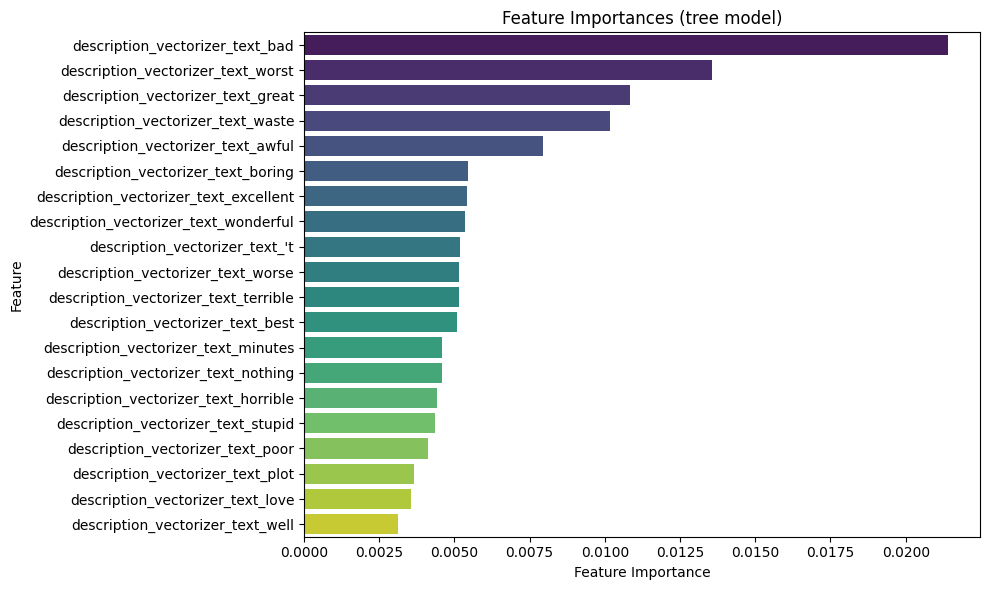

c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.

<Figure size 1500x600 with 0 Axes>

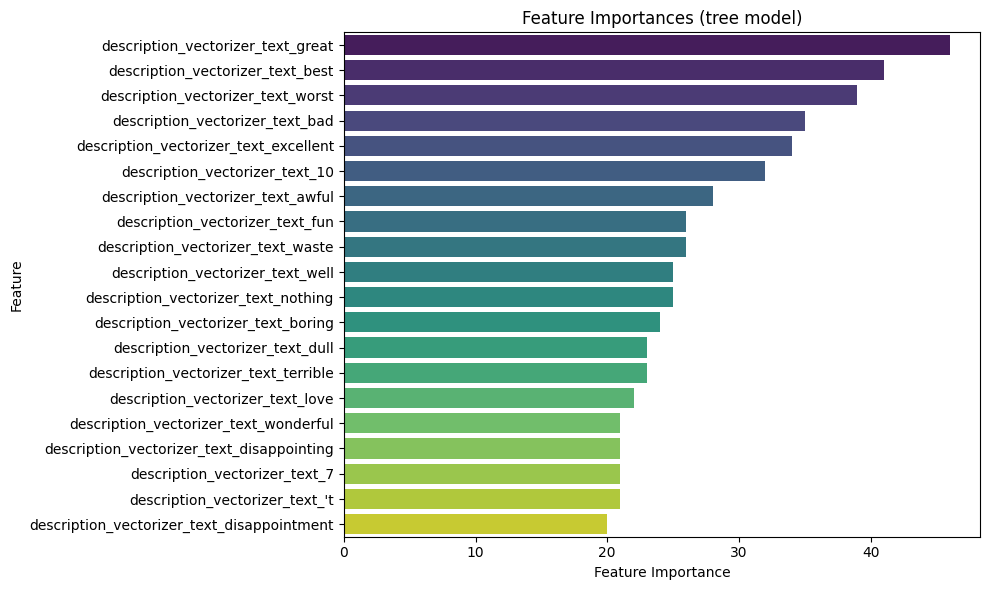

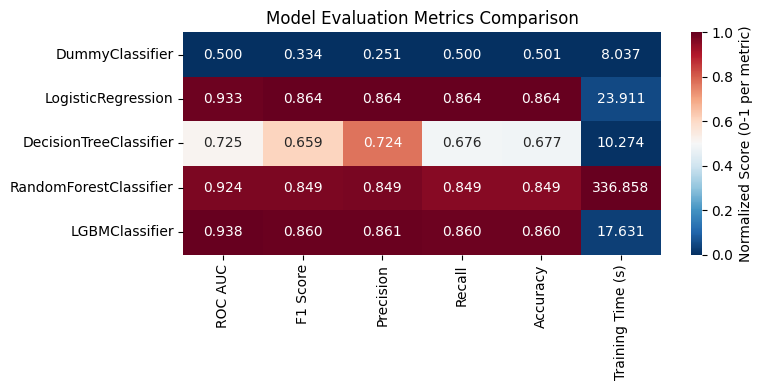

In [12]:
# Обучаем модели на очищенных от стоп-слов данных
# Сравним результаты с предыдущим экспериментом
count_vectorizer_cleaned_metrics = train_evaluate_models_cv(
    models=models,
    X=X_cleaned_tokens,
    y=y,
    preprocessor=count_vectorizer_preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 DummyClassifier         0.000000  0.000000   0.000000  0.000000  0.000000   
 LogisticRegression     -0.002886 -0.004151  -0.004175 -0.004152 -0.004154   
 DecisionTreeClassifier  0.000208  0.000124   0.000420  0.000175  0.000176   
 RandomForestClassifier  0.000658  0.003244   0.003328  0.003266  0.003247   
 LGBMClassifier         -0.002446 -0.004242  -0.004124 -0.004236 -0.004229   
 
                         Training Time (s)  Training Time (s) Change (%)  
 DummyClassifier                 -4.863012                    -37.698461  
 LogisticRegression             -41.004240                    -63.165684  
 DecisionTreeClassifier          -5.816079                    -36.147756  
 RandomForestClassifier         -61.572069                    -15.453677  
 LGBMClassifier                  -6.764144                    -27.727084  )

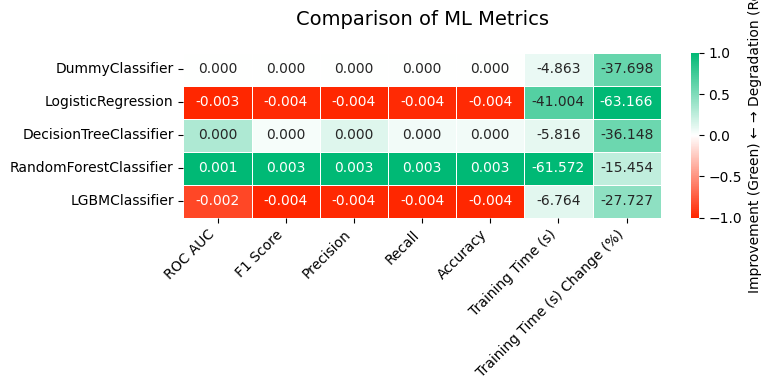

In [18]:
# Сравниваем метрики моделей до и после удаления стоп-слов
# Тепловая карта покажет, улучшилось ли качество после очистки
compare_metrics_heatmap(count_vectorizer_metrics.to_dataframe(), count_vectorizer_cleaned_metrics.to_dataframe())


Вывод по удалению стоп-слов:

Изменение метрик незначительное, однако наблюдается ускорение времени обучения. Это преобразование оставим, так как:

1. Ускоряет обучение без потери качества
2. Стоп-слова в наших текстах не несут дополнительной смысловой нагрузки
3. Уменьшает размерность признакового пространства

#### 2.1.3 Топ 100 важных токенов

In [19]:
# Создаем пайплайн с отбором топ-100 важных токенов
count_vectorizer_important_tokens_preprocessor = Pipeline([
    (
        'columns',
        ColumnTransformer([
            (
                'description_pipeline',
                Pipeline([
                    ('token_selector', NgramFeatureSelector(top_k=100)),
                    ('vectorizer', CountVectorizer(analyzer=lambda x: x, min_df=50, dtype=np.float32)),
                ]),
                'text'
            ),
        ],
            remainder='passthrough',
            verbose_feature_names_out=True
        )
    ),
])

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

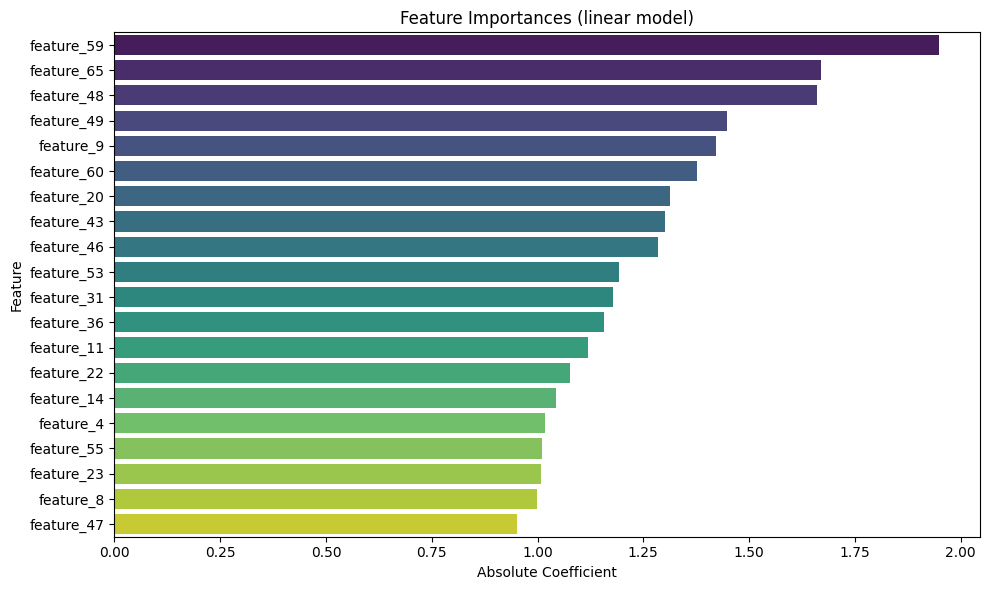

<Figure size 1500x600 with 0 Axes>

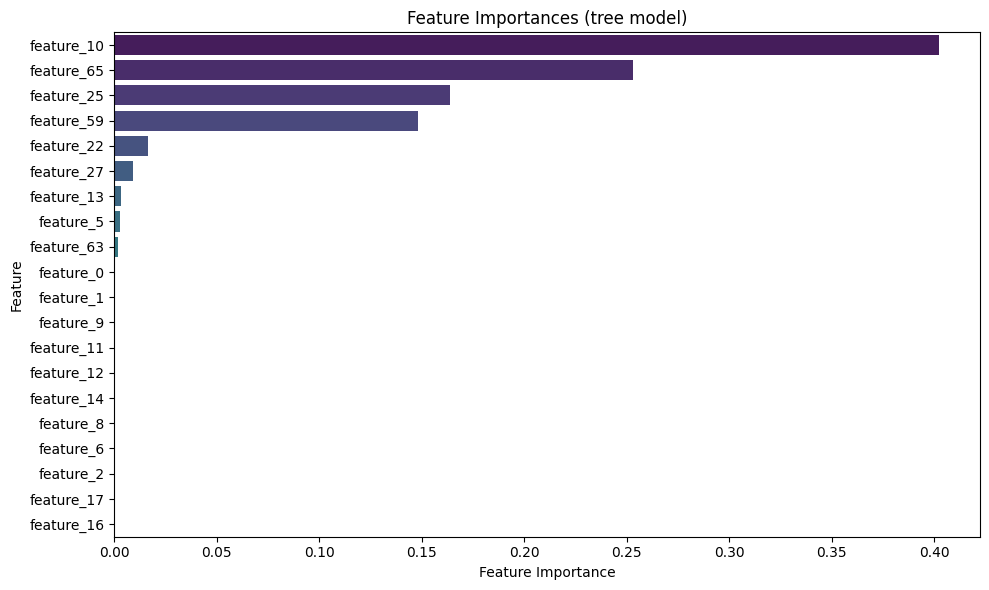

<Figure size 1500x600 with 0 Axes>

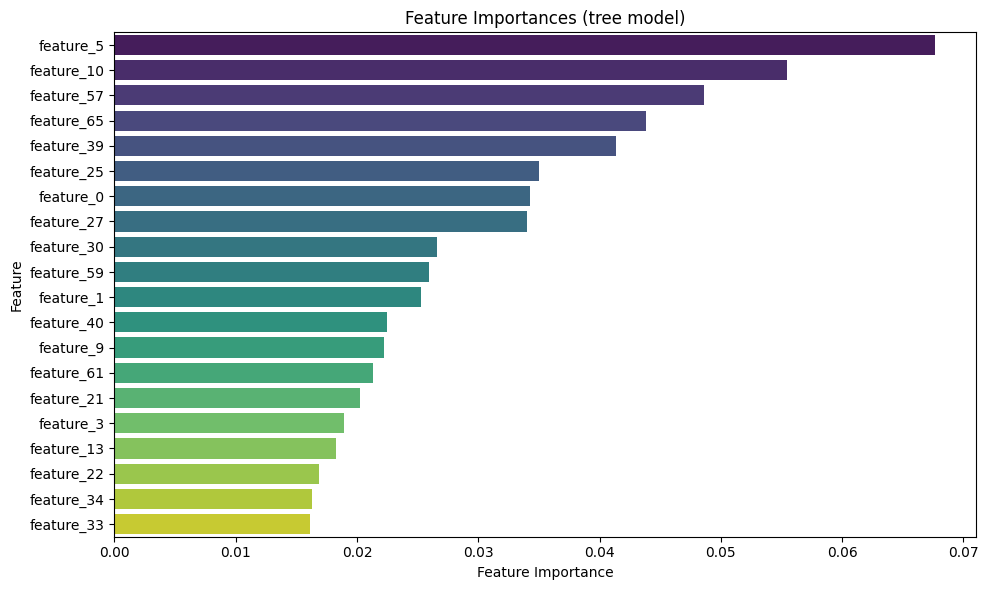

c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.

<Figure size 1500x600 with 0 Axes>

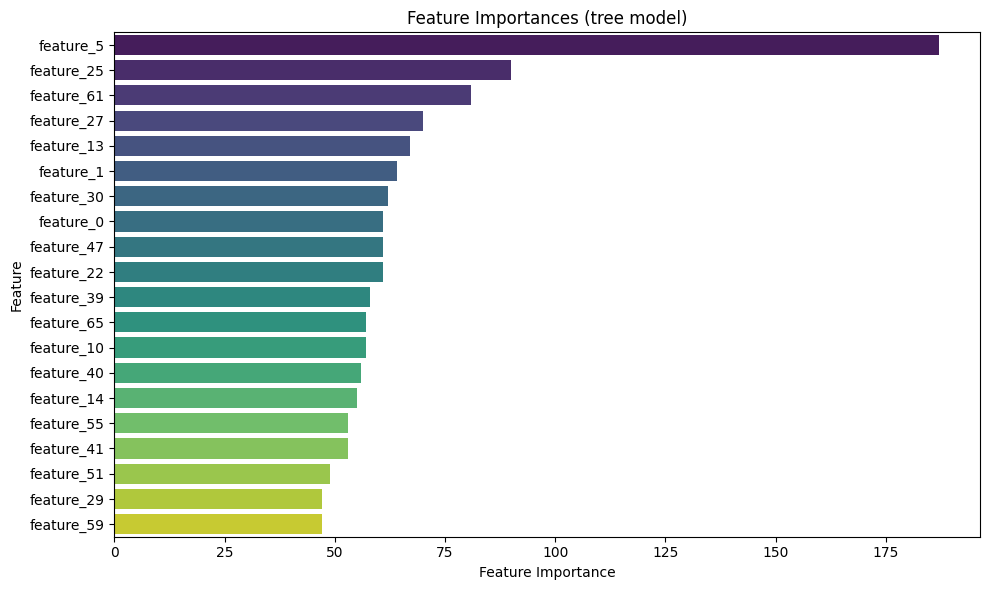

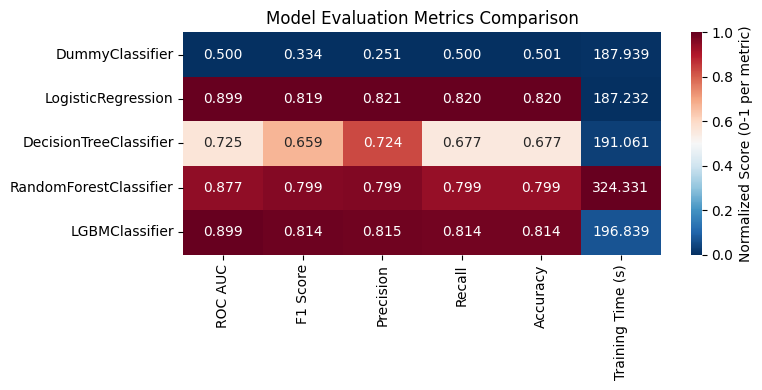

In [20]:
# Обучаем модели с отбором важных токенов
# Используем исходные данные (не очищенные от стоп-слов), так как отбор токенов делается на основе важности
count_vectorizer_important_tokens_metrics = train_evaluate_models_cv(
    models=models,
    X=X,
    y=y,
    preprocessor=count_vectorizer_important_tokens_preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 DummyClassifier         0.000000  0.000000   0.000000  0.000000  0.000000   
 LogisticRegression     -0.037136 -0.049000  -0.047253 -0.048838 -0.048763   
 DecisionTreeClassifier  0.000427  0.000294   0.000118  0.000227  0.000227   
 RandomForestClassifier -0.046553 -0.046271  -0.046147 -0.046268 -0.046245   
 LGBMClassifier         -0.041325 -0.050393  -0.050186 -0.050361 -0.050349   
 
                         Training Time (s)  Training Time (s) Change (%)  
 DummyClassifier                175.039066                   1356.917075  
 LogisticRegression             122.316890                    188.425149  
 DecisionTreeClassifier         174.970972                   1087.469439  
 RandomForestClassifier         -74.098963                    -18.597741  
 LGBMClassifier                 172.443635                    706.868273  )

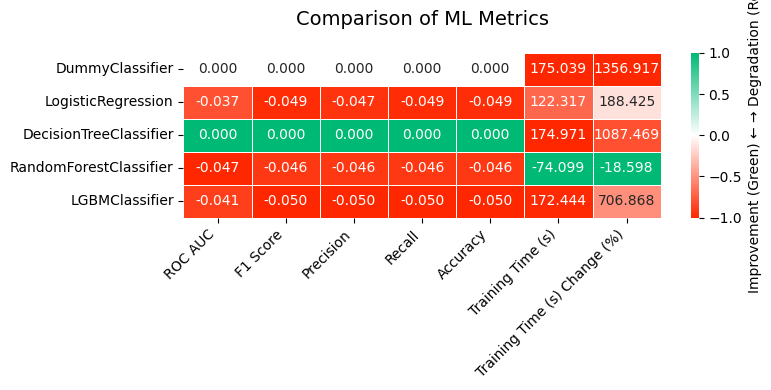

In [22]:
# Сравниваем результаты с отбором важных токенов и без него
compare_metrics_heatmap(count_vectorizer_metrics.to_dataframe(), count_vectorizer_important_tokens_metrics.to_dataframe())

Проблемы:

Сильно увеличилось время обучения за счет долгого пересчета n-грамм
Ухудшение качества 

### 2.2. TfidfVectorizer

#### 2.2.1 Без очистки токенов

In [23]:
# Создаем пайплайн для TF-IDF векторизации
tfidf_vectorizer_preprocessor = Pipeline([
    ('vectorizer', ColumnTransformer(
        [
            # TF-IDF векторизация описаний
            ('description_vectorizer', TfidfVectorizer(analyzer=lambda x: x, min_df=50, dtype=np.float32), 'text'),
        ],
        remainder='passthrough', 
        verbose_feature_names_out=True
    )),
])

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

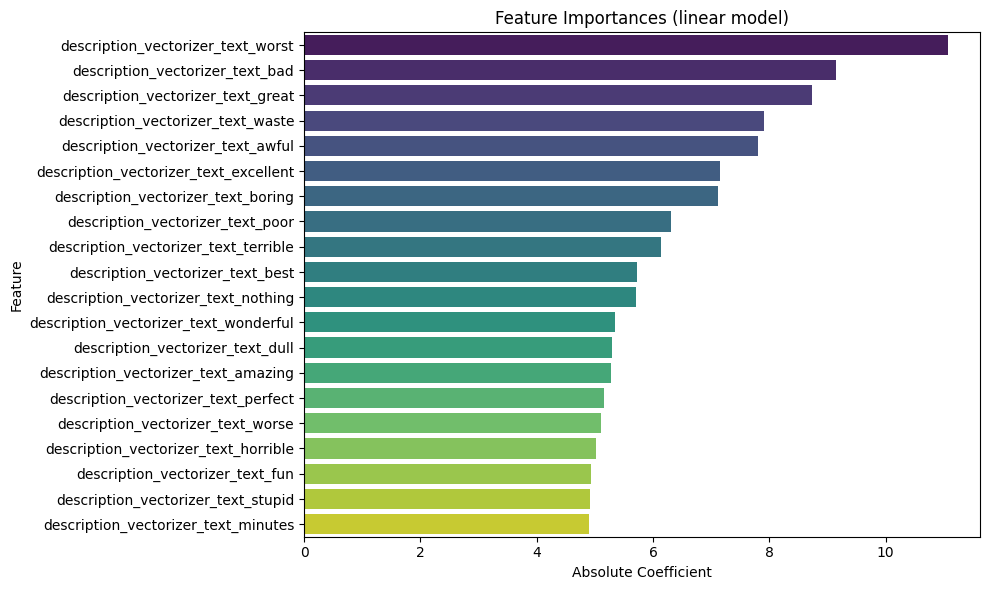

<Figure size 1500x600 with 0 Axes>

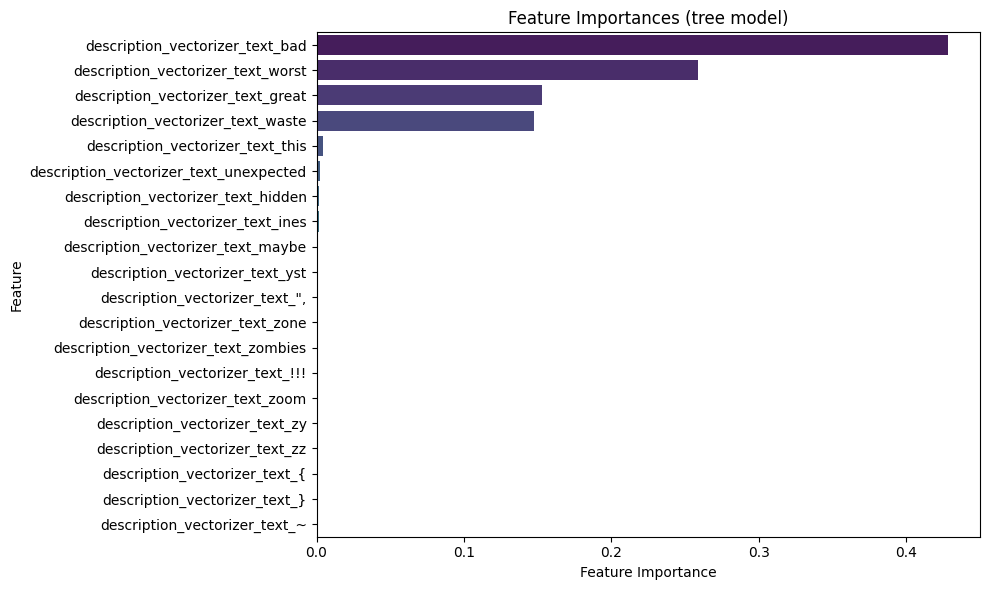

<Figure size 1500x600 with 0 Axes>

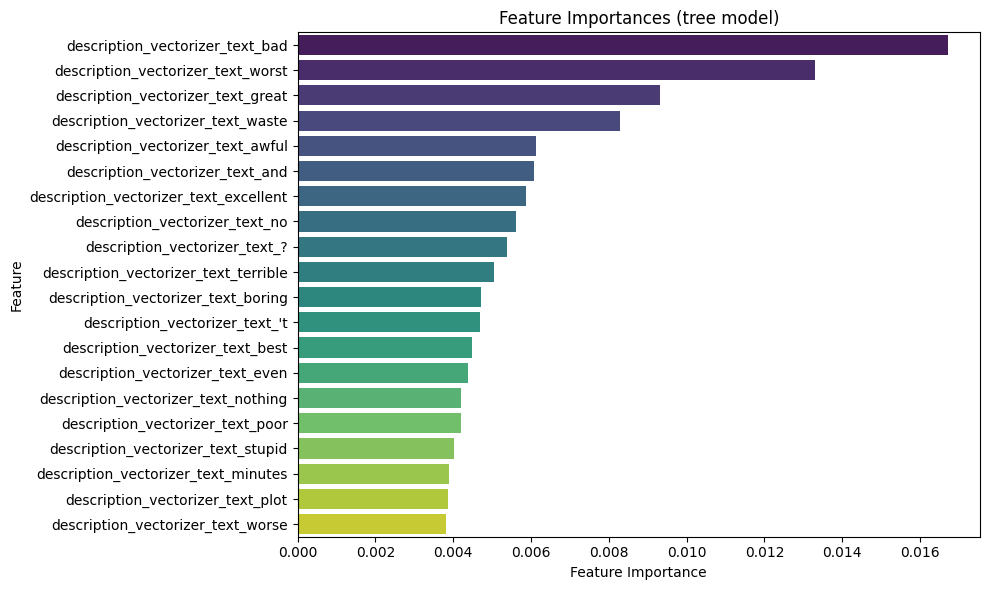

c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.

<Figure size 1500x600 with 0 Axes>

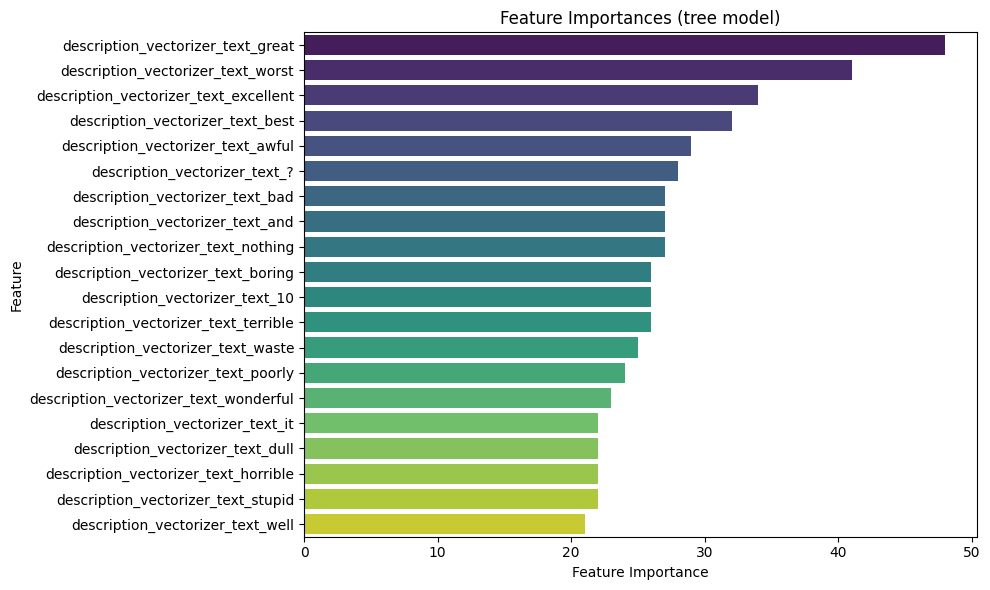

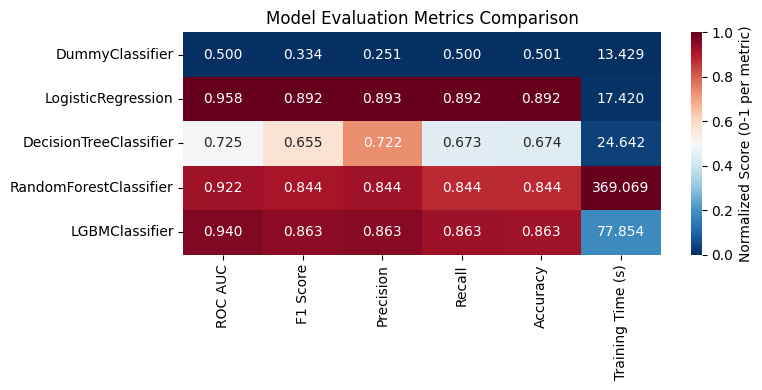

In [24]:
# Обучаем модели с TF-IDF векторизацией на исходных данных
tfidf_vectorizer_metrics = train_evaluate_models_cv(
    models=models,
    X=X,
    y=y,
    preprocessor=tfidf_vectorizer_preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 DummyClassifier         0.000000  0.000000   0.000000  0.000000  0.000000   
 LogisticRegression      0.021474  0.023905   0.024039  0.023899  0.023916   
 DecisionTreeClassifier  0.000055 -0.003819  -0.001519 -0.003004 -0.002996   
 RandomForestClassifier -0.001158 -0.001721  -0.001575 -0.001688 -0.001712   
 LGBMClassifier          0.000093 -0.001201  -0.001280 -0.001204 -0.001208   
 
                         Training Time (s)  Training Time (s) Change (%)  
 DummyClassifier                  0.528974                      4.100652  
 LogisticRegression             -47.495276                    -73.164912  
 DecisionTreeClassifier           8.552195                     53.153104  
 RandomForestClassifier         -29.361018                     -7.369180  
 LGBMClassifier                  53.458213                    219.131977  )

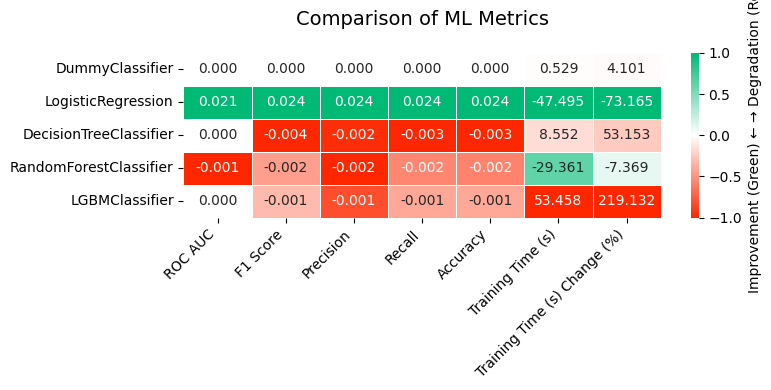

In [25]:
# Сравниваем CountVectorizer и TfidfVectorizer
compare_metrics_heatmap(count_vectorizer_metrics.to_dataframe(), tfidf_vectorizer_metrics.to_dataframe())

#### 2.2.2 Удаление стоп-слов

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

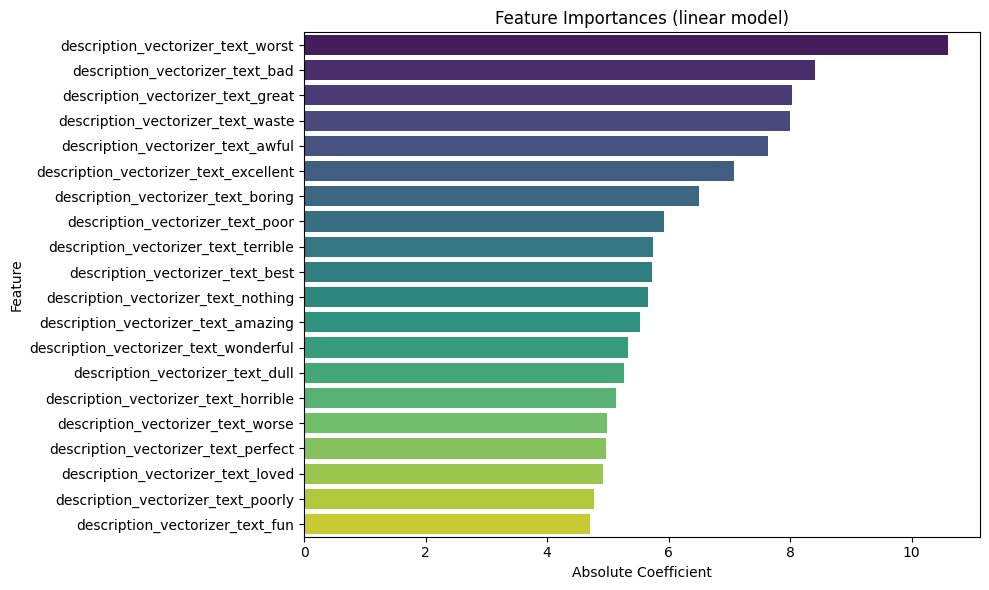

<Figure size 1500x600 with 0 Axes>

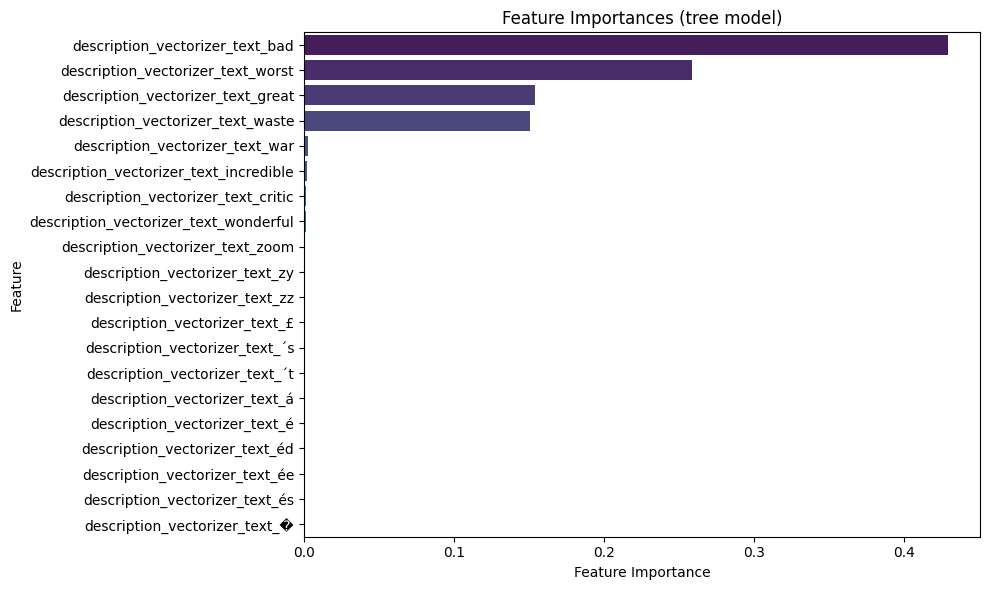

<Figure size 1500x600 with 0 Axes>

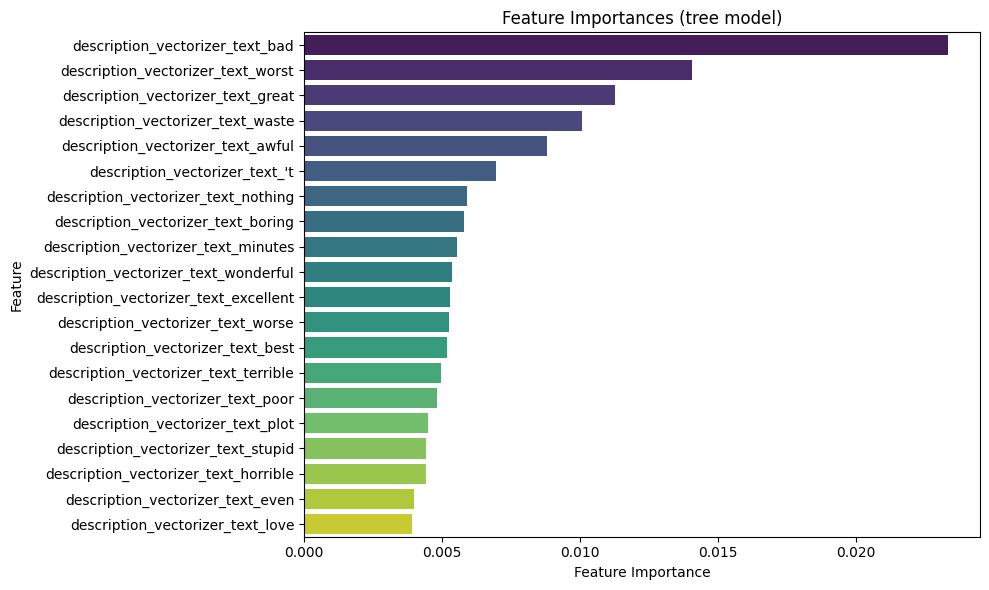

c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.

<Figure size 1500x600 with 0 Axes>

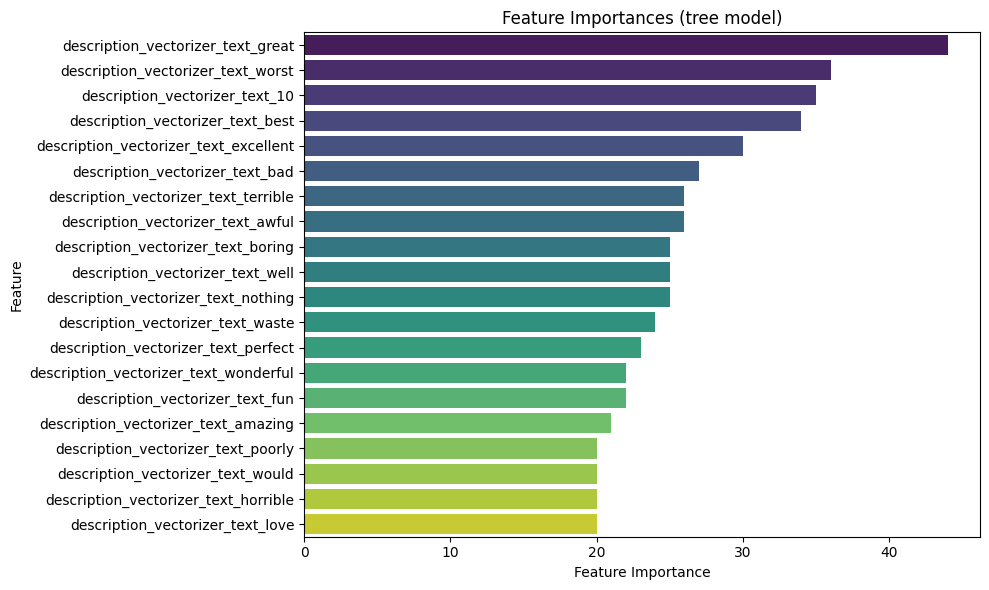

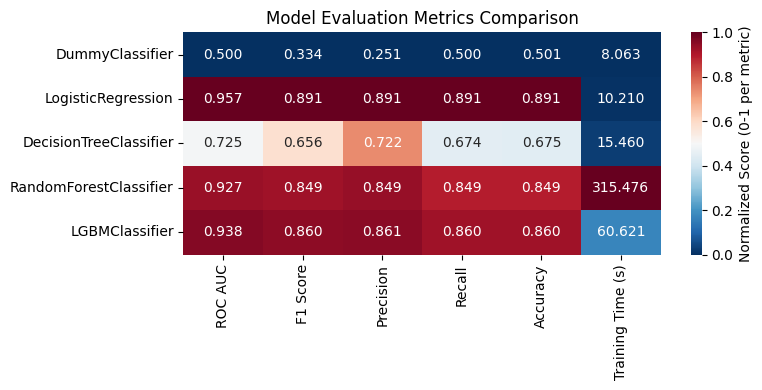

In [26]:
# Обучаем TF-IDF модели на данных без стоп-слов
tfidf_vectorizer_clean_metrics = train_evaluate_models_cv(
    models=models,
    X=X_cleaned_tokens,
    y=y,
    preprocessor=tfidf_vectorizer_preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 DummyClassifier         0.000000  0.000000   0.000000  0.000000  0.000000   
 LogisticRegression      0.023688  0.026363   0.026608  0.026358  0.026383   
 DecisionTreeClassifier -0.000092 -0.002940  -0.001636 -0.002421 -0.002417   
 RandomForestClassifier  0.002441  0.000096   0.000158  0.000106  0.000101   
 LGBMClassifier          0.000667  0.000265   0.000132  0.000259  0.000252   
 
                         Training Time (s)  Training Time (s) Change (%)  
 DummyClassifier                  0.026634                      0.331408  
 LogisticRegression             -13.700994                    -57.299639  
 DecisionTreeClassifier           5.186682                     50.485246  
 RandomForestClassifier         -21.381421                     -6.347313  
 LGBMClassifier                  42.989784                    243.826559  )

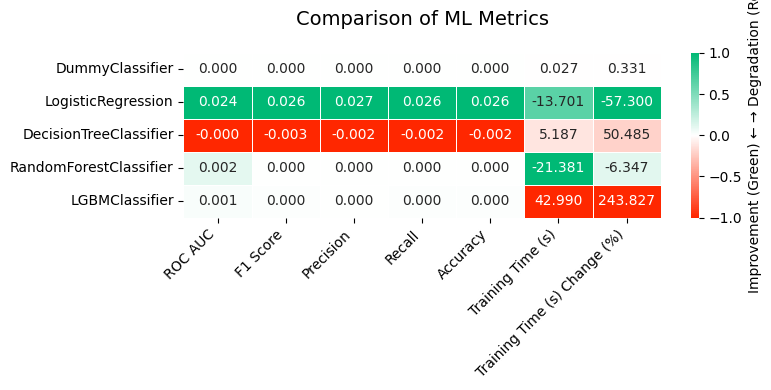

In [27]:
# Сравниваем CountVectorizer и TfidfVectorizer на очищенных данных
compare_metrics_heatmap(count_vectorizer_cleaned_metrics.to_dataframe(), tfidf_vectorizer_clean_metrics.to_dataframe())